In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet("processed_data/super_df.parquet")

In [3]:
# 1️⃣ Filtrar solo Both sexes
df = df[df["sex"] == "Both sexes"].copy()

# 2️⃣ Eliminar la columna sex
df = df.drop(columns=["sex"])

# 3️⃣ Verificar
print(df.head())
print("Shape:", df.shape)

                   region country_code                           country  \
3                Americas          VCT  Saint Vincent and the Grenadines   
16  Eastern Mediterranean          JOR                            Jordan   
17  Eastern Mediterranean          LBN                           Lebanon   
18  Eastern Mediterranean          SYR                             Syria   
20  Eastern Mediterranean          EGY                             Egypt   

    year  suicide_rates           gdp  inflation   unemp   labor  governance  \
3   2021           0.29  16200.899460   1.572729  20.356  66.756    0.306391   
16  2021           0.67   9182.496161   1.346094  19.837  38.670    0.194550   
17  2021           0.70  11599.775508        NaN  12.715  45.518   -1.312259   
18  2021           0.66           NaN        NaN  14.887  36.334   -1.767034   
20  2021           0.73  15579.016086   5.214049   7.441  42.987   -0.457697   

    tertiaryeduc  gini  poverty   literacy  homicides  alcohol

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 4070 entries, 3 to 12208
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   region               4070 non-null   str    
 1   country_code         4070 non-null   str    
 2   country              4070 non-null   str    
 3   year                 4070 non-null   int64  
 4   suicide_rates        4070 non-null   float64
 5   gdp                  3894 non-null   float64
 6   inflation            3630 non-null   float64
 7   unemp                3960 non-null   float64
 8   labor                3960 non-null   float64
 9   governance           4011 non-null   float64
 10  tertiaryeduc         1976 non-null   float64
 11  gini                 2516 non-null   float64
 12  poverty              2516 non-null   float64
 13  literacy             1669 non-null   float64
 14  homicides            2917 non-null   float64
 15  alcohol_consumption  4004 non-null   float64
 16  cor

In [5]:
df[["gdp","homicides","depression_rate","drug_use_rate"]].skew()

gdp                2.381399
homicides          2.915019
depression_rate    0.963932
drug_use_rate      1.846933
dtype: float64

In [6]:
import numpy as np

df_model = df.copy()

df_model["log_gdp"] = np.log(df_model["gdp"])
df_model["log_homicides"] = np.log(df_model["homicides"] + 1)
df_model["log_drug_use_rate"] = np.log(df_model["drug_use_rate"] + 1)
df_model["log_depression_rate"] = np.log(df_model["depression_rate"] + 1)

In [7]:
df_model[[
    "log_gdp",
    "log_homicides",
    "log_drug_use_rate",
    "log_depression_rate"
]].skew()

log_gdp               -0.166959
log_homicides          0.730614
log_drug_use_rate      0.090755
log_depression_rate    0.175408
dtype: float64

MODELO 1 — Núcleo Salud (máxima muestra)

Variables:

log_depression_rate

log_drug_use_rate

alcohol_consumption

Aquí conservarás casi las 12,000 observaciones.

In [8]:
features_m1 = [
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption"
]

y = "suicide_rates"

model_df_m1 = df_model[[y] + features_m1].dropna()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
model_df_m1[features_m1] = scaler.fit_transform(model_df_m1[features_m1])

import statsmodels.api as sm

X = sm.add_constant(model_df_m1[features_m1])
y_values = model_df_m1[y]

model_m1 = sm.OLS(y_values, X).fit()

print(model_m1.summary())

                            OLS Regression Results                            
Dep. Variable:          suicide_rates   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     115.3
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.34e-71
Time:                        14:40:03   Log-Likelihood:                -13267.
No. Observations:                4004   AIC:                         2.654e+04
Df Residuals:                    4000   BIC:                         2.657e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  10.3310    

In [9]:
features_m1 = [
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption"
]

y = "suicide_rates"

model_df_m1 = df_model[
    [y] + features_m1 + ["country", "year"]
].dropna()

print("Observaciones:", len(model_df_m1))

Observaciones: 4004


In [10]:
import statsmodels.formula.api as smf

model_fe = smf.ols(
    "suicide_rates ~ log_depression_rate + log_drug_use_rate + alcohol_consumption + C(country) + C(year)",
    data=model_df_m1
).fit()

print(model_fe.summary())

                            OLS Regression Results                            
Dep. Variable:          suicide_rates   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     224.8
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:40:03   Log-Likelihood:                -8277.5
No. Observations:                4004   AIC:                         1.697e+04
Df Residuals:                    3798   BIC:                         1.826e+04
Df Model:                         205                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [11]:
model_fe.params[["log_depression_rate",
                 "log_drug_use_rate",
                 "alcohol_consumption"]]

log_depression_rate    6.419082
log_drug_use_rate      6.094261
alcohol_consumption    0.103353
dtype: float64

In [12]:
model_fe.pvalues[["log_depression_rate",
                   "log_drug_use_rate",
                   "alcohol_consumption"]]

log_depression_rate    3.744670e-15
log_drug_use_rate      3.501261e-26
alcohol_consumption    1.625108e-02
dtype: float64

Primero, preparamos el conjunto de datos para realizar un análisis explicativo con estructura de panel (país–año–sexo), cuyo objetivo es identificar qué variables influyen en las tasas de suicidio y en qué magnitud. Dado que algunas variables presentaban una fuerte asimetría hacia la derecha (especialmente el PIB, los homicidios y el consumo de drogas, y en menor medida la depresión), aplicamos transformaciones logarítmicas. Esta transformación se utilizó porque mejora la simetría de la distribución, reduce la influencia de valores extremos y favorece una relación más lineal entre las variables explicativas y la variable dependiente, lo cual es importante para la validez de un modelo de regresión lineal.

Posteriormente, estimamos dos modelos distintos para comparar resultados y comprender mejor la naturaleza de las relaciones encontradas. El primer modelo fue una regresión OLS simple (pooled OLS), que trata todas las observaciones como independientes y capta principalmente diferencias entre países. Este modelo reflejaba asociaciones generales, pero no controlaba por características estructurales propias de cada país que no cambian en el tiempo, como cultura, religión, nivel estructural de desarrollo, sistemas de salud o calidad del registro estadístico. Por ello, sus resultados pueden estar sesgados al mezclar efectos estructurales entre países con cambios reales dentro de cada país.

Para corregir esto, estimamos un segundo modelo con efectos fijos por país y por año. Al incluir variables indicadoras (dummies) para cada país y cada año, este modelo controla por todas las características constantes en el tiempo de cada país y por choques globales comunes en determinados años. En consecuencia, los coeficientes del modelo de efectos fijos se interpretan como variaciones dentro del mismo país a lo largo del tiempo. Es decir, permiten responder a la pregunta: cuando una variable cambia dentro de un país, ¿cómo cambia la tasa de suicidio en ese mismo país?

La diferencia entre ambos modelos es fundamental. El modelo OLS simple compara países entre sí, mientras que el modelo con efectos fijos compara a cada país consigo mismo a lo largo del tiempo. En nuestro caso, los resultados cambiaron de manera importante al introducir efectos fijos, lo que indica que parte de las relaciones observadas inicialmente estaban influenciadas por diferencias estructurales entre países. Con efectos fijos, las variables de depresión y consumo de drogas mostraron una asociación positiva y estadísticamente significativa con el suicidio, lo que sugiere que aumentos en estas variables dentro de un país se relacionan con aumentos en las tasas de suicidio. En cambio, el consumo de alcohol dejó de ser estadísticamente significativo, lo que sugiere que su efecto aparente en el modelo simple estaba más asociado a diferencias estructurales entre países que a cambios temporales dentro de ellos.

En síntesis, el segundo modelo ofrece una interpretación más robusta y metodológicamente sólida para un análisis longitudinal comparativo, ya que permite aislar los efectos dinámicos dentro de cada país y reduce el sesgo por variables omitidas constantes en el tiempo.

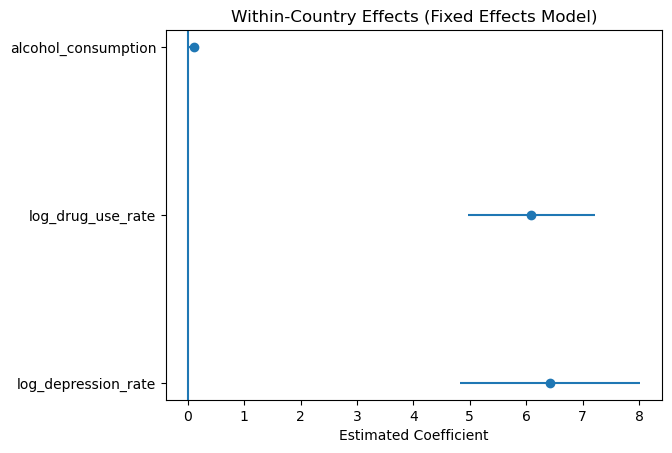

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Seleccionamos solo variables clave
variables = ["log_depression_rate",
             "log_drug_use_rate",
             "alcohol_consumption"]

coefs = model_fe.params[variables]
conf = model_fe.conf_int().loc[variables]

# Crear gráfica
plt.figure()
plt.errorbar(coefs, variables,
             xerr=[coefs - conf[0], conf[1] - coefs],
             fmt='o')
plt.axvline(0)
plt.xlabel("Estimated Coefficient")
plt.title("Within-Country Effects (Fixed Effects Model)")
plt.show()

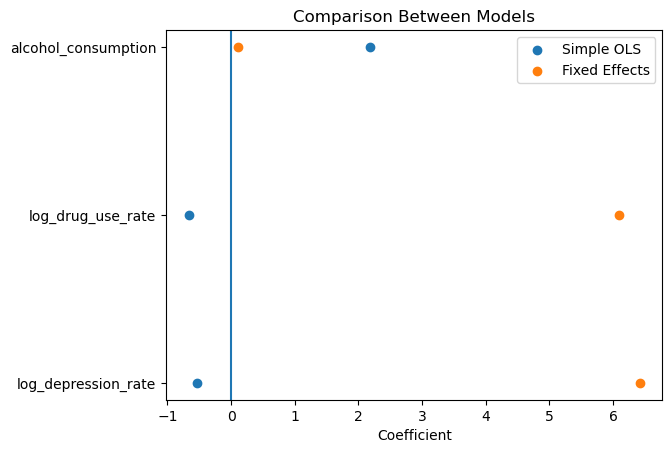

<Figure size 640x480 with 0 Axes>

In [47]:
coefs_simple = model_m1.params[variables]
coefs_fe = model_fe.params[variables]

plt.figure()
plt.scatter(coefs_simple, variables)
plt.scatter(coefs_fe, variables)

plt.axvline(0)
plt.legend(["Simple OLS", "Fixed Effects"])
plt.xlabel("Coefficient")
plt.title("Comparison Between Models")
plt.show()
# Guardar imagen
plt.savefig("model_comparison_coefficients.png", dpi=300, bbox_inches="tight")

plt.show()

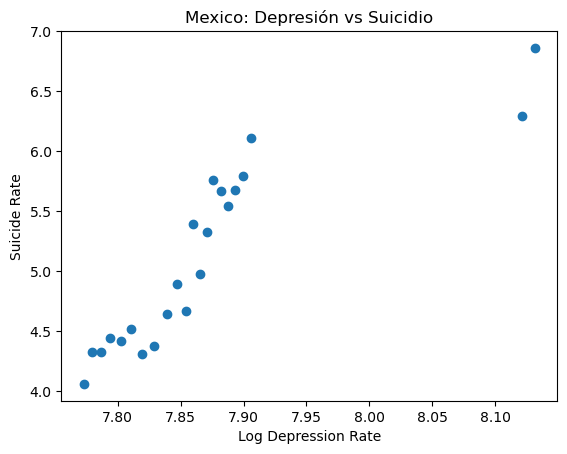

In [15]:
country_example = "Mexico"  # cambia por el que quieras

subset = df_model[df_model["country"] == country_example]

plt.figure()
plt.scatter(subset["log_depression_rate"],
            subset["suicide_rates"])
plt.xlabel("Log Depression Rate")
plt.ylabel("Suicide Rate")
plt.title(f"{country_example}: Depresión vs Suicidio")
plt.show()

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_base = model_df_m1[["log_depression_rate",
                      "log_drug_use_rate",
                      "alcohol_consumption"]]

vif_data = pd.DataFrame()
vif_data["Variable"] = X_base.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_base.values, i)
    for i in range(X_base.shape[1])
]

print(vif_data)

              Variable         VIF
0  log_depression_rate  149.336535
1    log_drug_use_rate  162.769752
2  alcohol_consumption    3.331050


In [17]:
df_model[["log_depression_rate",
          "log_drug_use_rate"]].corr()

,log_depression_rate,log_drug_use_rate
log_depression_rate,1.000000,0.246926
log_drug_use_rate,0.246926,1.000000


In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_clean = model_df_m1[[
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption"
]].copy()

vif_data = pd.DataFrame()
vif_data["Variable"] = X_clean.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_clean.values, i)
    for i in range(X_clean.shape[1])
]

print(vif_data)

              Variable         VIF
0  log_depression_rate  149.336535
1    log_drug_use_rate  162.769752
2  alcohol_consumption    3.331050


In [19]:
within_std = df_model.groupby("country")[[
    "log_depression_rate",
    "log_drug_use_rate"
]].std()

print(within_std.describe())

       log_depression_rate  log_drug_use_rate
count           185.000000         185.000000
mean              0.085523           0.046116
std               0.026886           0.036514
min               0.028320           0.004743
25%               0.066997           0.021394
50%               0.079396           0.036108
75%               0.101710           0.063527
max               0.191904           0.224082


# En el Bloque 2 no solo queremos ver si economía influye en suicidio.

Queremos responder algo más profundo:

¿Las variables de salud mental siguen siendo fuertes cuando controlamos por condiciones económicas?

In [20]:
features_m2 = [
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption",
    "log_gdp",
    "unemp",
    "inflation"
]

y = "suicide_rates"

model_df_m2 = df_model[
    [y] + features_m2 + ["country", "year"]
].dropna()

print("Observaciones Modelo 2:", len(model_df_m2))

Observaciones Modelo 2: 3457


In [21]:
print("Países:", model_df_m2["country"].nunique())
print("Años:", model_df_m2["year"].nunique())

Países: 159
Años: 22


In [22]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

# =========================
# 0) Copia de trabajo
# =========================
df_model = df.copy()

# =========================
# 1) Transformaciones log (según tus columnas reales)
# =========================
# Nota: gdp debe ser > 0; homicides/drug/depression se protege con +1 por si hay ceros
df_model["log_gdp"] = np.log(df_model["gdp"])
df_model["log_homicides"] = np.log(df_model["homicides"] + 1)
df_model["log_drug_use_rate"] = np.log(df_model["drug_use_rate"] + 1)
df_model["log_depression_rate"] = np.log(df_model["depression_rate"] + 1)

# =========================
# 2) Modelo 2: Salud + Economía (FE país + FE año)
# =========================
features_m2 = [
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption",
    "log_gdp",
    "unemp",
    "inflation"
]
y = "suicide_rates"

# Dataset del modelo (incluye país y año para efectos fijos)
model_df_m2 = df_model[[y] + features_m2 + ["country", "year"]].dropna()

print("Observaciones Modelo 2:", len(model_df_m2))
print("Países:", model_df_m2["country"].nunique())
print("Años:", model_df_m2["year"].nunique())

# =========================
# 3) (Recomendado) Estandarizar SOLO X para comparar magnitudes
# =========================
scaler = StandardScaler()
model_df_m2[features_m2] = scaler.fit_transform(model_df_m2[features_m2])

# =========================
# 4) Estimación con efectos fijos y errores clusterizados por país
# =========================
formula_m2 = (
    "suicide_rates ~ "
    "log_depression_rate + log_drug_use_rate + alcohol_consumption + "
    "log_gdp + unemp + inflation + "
    "C(country) + C(year)"
)

model_fe_m2 = smf.ols(
    formula=formula_m2,
    data=model_df_m2
).fit(
    cov_type="cluster",
    cov_kwds={"groups": model_df_m2["country"]}
)

print(model_fe_m2.summary())

# =========================
# 5) Extra: tabla rápida solo con coeficientes/p-values de interés
# =========================
vars_show = [
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption",
    "log_gdp",
    "unemp",
    "inflation"
]

print("\n=== Coeficientes (Modelo 2) ===")
print(model_fe_m2.params[vars_show])

print("\n=== p-values (Modelo 2) ===")
print(model_fe_m2.pvalues[vars_show])

print("\n=== Intervalos de confianza 95% (Modelo 2) ===")
print(model_fe_m2.conf_int().loc[vars_show])

Observaciones Modelo 2: 3457
Países: 159
Años: 22
                            OLS Regression Results                            
Dep. Variable:          suicide_rates   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     306.8
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          2.18e-122
Time:                        14:40:04   Log-Likelihood:                -7128.6
No. Observations:                3457   AIC:                         1.463e+04
Df Residuals:                    3271   BIC:                         1.577e+04
Df Model:                         185                                         
Covariance Type:              cluster                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------

/opt/miniconda3/envs/dataenv/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 185, but rank is 27
  warnings.warn('covariance of constraints does not have full '


In [23]:
print(model_fe_m2.params[[
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption",
    "log_gdp",
    "unemp",
    "inflation"
]])

print(model_fe_m2.pvalues[[
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption",
    "log_gdp",
    "unemp",
    "inflation"
]])

log_depression_rate    1.625076
log_drug_use_rate      3.164102
alcohol_consumption    1.297313
log_gdp               -3.295467
unemp                  0.871979
inflation              0.034415
dtype: float64
log_depression_rate    0.007008
log_drug_use_rate      0.057436
alcohol_consumption    0.072090
log_gdp                0.000696
unemp                  0.000095
inflation              0.629065
dtype: float64


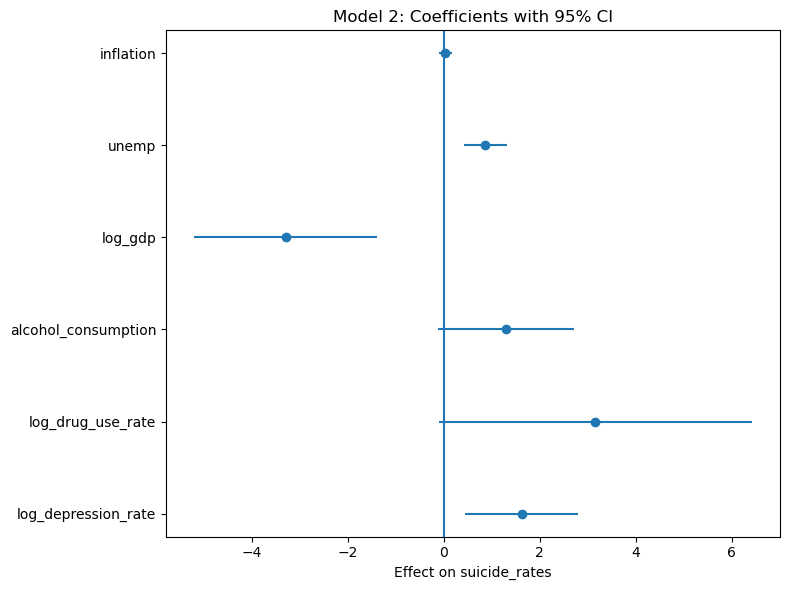

In [43]:
import matplotlib.pyplot as plt
import numpy as np

vars_plot = [
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption",
    "log_gdp",
    "unemp",
    "inflation"
]

coefs = model_fe_m2.params[vars_plot]
conf = model_fe_m2.conf_int().loc[vars_plot]

plt.figure(figsize=(8,6))

plt.errorbar(
    coefs,
    range(len(coefs)),
    xerr=[
        coefs - conf[0],
        conf[1] - coefs
    ],
    fmt='o'
)

plt.axvline(0)
plt.yticks(range(len(coefs)), vars_plot)
plt.title("Model 2: Coefficients with 95% CI")
plt.xlabel("Effect on suicide_rates")
plt.tight_layout()
plt.show()


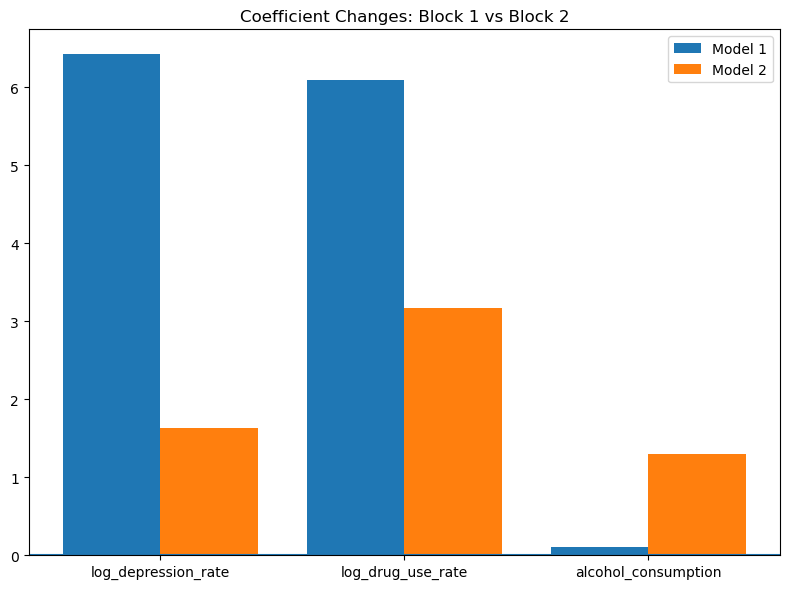

In [44]:
vars_compare = [
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption"
]

coef_m1 = model_fe.params[vars_compare]
coef_m2 = model_fe_m2.params[vars_compare]

x = np.arange(len(vars_compare))

plt.figure(figsize=(8,6))

plt.bar(x - 0.2, coef_m1, width=0.4, label="Model 1")
plt.bar(x + 0.2, coef_m2, width=0.4, label="Model 2")

plt.xticks(x, vars_compare)
plt.axhline(0)
plt.title("Coefficient Changes: Block 1 vs Block 2")
plt.legend()
plt.tight_layout()
plt.show()

# 🔹 BLOQUE 3A — Desigualdad

In [30]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

# =========================
# 1) Variables Bloque 3A
# =========================

features_m3A = [
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption",
    "log_gdp",
    "unemp",
    "inflation",
    "gini",
    "poverty"
]

y = "suicide_rates"

model_df_m3A = df_model[[y] + features_m3A + ["country", "year"]].dropna()

print("Observaciones Modelo 3A:", len(model_df_m3A))
print("Países:", model_df_m3A["country"].nunique())
print("Años:", model_df_m3A["year"].nunique())

# =========================
# 2) Estandarizar variables explicativas
# =========================

scaler = StandardScaler()
model_df_m3A[features_m3A] = scaler.fit_transform(model_df_m3A[features_m3A])

# =========================
# 3) Modelo con FE + cluster
# =========================

formula_m3A = (
    "suicide_rates ~ "
    "log_depression_rate + log_drug_use_rate + alcohol_consumption + "
    "log_gdp + unemp + inflation + "
    "gini + poverty + "
    "C(country) + C(year)"
)

model_fe_m3A = smf.ols(
    formula=formula_m3A,
    data=model_df_m3A
).fit(
    cov_type="cluster",
    cov_kwds={"groups": model_df_m3A["country"]}
)

print(model_fe_m3A.summary())

Observaciones Modelo 3A: 2356
Países: 128
Años: 22
                            OLS Regression Results                            
Dep. Variable:          suicide_rates   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     126.5
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           5.24e-80
Time:                        15:08:50   Log-Likelihood:                -4646.9
No. Observations:                2356   AIC:                             9608.
Df Residuals:                    2199   BIC:                         1.051e+04
Df Model:                         156                                         
Covariance Type:              cluster                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

/opt/miniconda3/envs/dataenv/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 156, but rank is 29
  warnings.warn('covariance of constraints does not have full '


In [31]:
vars_show_3A = [
"log_depression_rate",
"log_drug_use_rate",
"alcohol_consumption",
"log_gdp",
"unemp",
"inflation",
"gini",
"poverty"
]

print(model_fe_m3A.params[vars_show_3A])
print(model_fe_m3A.pvalues[vars_show_3A])

log_depression_rate    2.316237
log_drug_use_rate      2.545725
alcohol_consumption    2.138421
log_gdp               -6.673043
unemp                  0.764534
inflation              0.045530
gini                   0.074555
poverty               -0.825013
dtype: float64
log_depression_rate    0.003587
log_drug_use_rate      0.167354
alcohol_consumption    0.017076
log_gdp                0.000213
unemp                  0.000536
inflation              0.646704
gini                   0.838337
poverty                0.062649
dtype: float64


# =========================
# BLOQUE 3B
# ==============

In [32]:
# =========================
# BLOQUE 3B
# =========================

features_m3B = [
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption",
    "log_gdp",
    "unemp",
    "inflation",
    "gini",
    "poverty",
    "tertiaryeduc",
    "literacy"
]

y = "suicide_rates"

model_df_m3B = df_model[[y] + features_m3B + ["country", "year"]].dropna()

print("Observaciones Modelo 3B:", len(model_df_m3B))
print("Países:", model_df_m3B["country"].nunique())
print("Años:", model_df_m3B["year"].nunique())

# Estandarizar
scaler = StandardScaler()
model_df_m3B[features_m3B] = scaler.fit_transform(model_df_m3B[features_m3B])

formula_m3B = (
    "suicide_rates ~ "
    "log_depression_rate + log_drug_use_rate + alcohol_consumption + "
    "log_gdp + unemp + inflation + "
    "gini + poverty + "
    "tertiaryeduc + literacy + "
    "C(country) + C(year)"
)

model_fe_m3B = smf.ols(
    formula=formula_m3B,
    data=model_df_m3B
).fit(
    cov_type="cluster",
    cov_kwds={"groups": model_df_m3B["country"]}
)

print(model_fe_m3B.summary())

Observaciones Modelo 3B: 640
Países: 44
Años: 22
                            OLS Regression Results                            
Dep. Variable:          suicide_rates   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     359.5
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           5.21e-43
Time:                        15:13:01   Log-Likelihood:                -1103.8
No. Observations:                 640   AIC:                             2358.
Df Residuals:                     565   BIC:                             2692.
Df Model:                          74                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

/opt/miniconda3/envs/dataenv/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 74, but rank is 31
  warnings.warn('covariance of constraints does not have full '


In [33]:
within_std = df_model.groupby("country")[[
    "gini",
    "poverty",
    "tertiaryeduc",
    "literacy"
]].std()

within_std.describe()

,gini,poverty,tertiaryeduc,literacy
count,139.000000,139.000000,92.000000,107.000000
mean,2.187539,4.767568,9.174532,3.083430
std,1.228184,5.080747,6.326229,2.346960
min,0.323620,0.016503,1.076555,0.057318
25%,1.169819,0.499995,4.601109,1.255906
50%,1.907082,3.172082,7.731774,2.481047
75%,3.038640,7.184299,11.939674,4.321991
max,6.345677,27.087119,35.840365,10.673945


In [34]:
within_std_compare = df_model.groupby("country")[[
    "log_depression_rate",
    "log_gdp",
    "unemp"
]].std()

within_std_compare.describe()

,log_depression_rate,log_gdp,unemp
count,185.000000,177.000000,180.000000
mean,0.085523,0.295388,1.681976
std,0.026886,0.118693,1.363819
min,0.028320,0.074242,0.083473
25%,0.066997,0.211853,0.680050
50%,0.079396,0.278896,1.308237
75%,0.101710,0.364775,2.324359
max,0.191904,0.607350,6.772087


In [50]:
vars_show_3B = [
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption",
    "log_gdp",
    "unemp",
    "inflation",
    "gini",
    "poverty",
    "tertiaryeduc",
    "literacy"
]

print(model_fe_m3B.params[vars_show_3B])
print(model_fe_m3B.pvalues[vars_show_3B])

log_depression_rate    0.797660
log_drug_use_rate      5.105811
alcohol_consumption    1.591077
log_gdp               -3.106500
unemp                  1.111354
inflation              0.100466
gini                   0.050203
poverty                0.303310
tertiaryeduc           0.278554
literacy              -1.186697
dtype: float64
log_depression_rate    0.550913
log_drug_use_rate      0.021246
alcohol_consumption    0.057174
log_gdp                0.045116
unemp                  0.003053
inflation              0.376675
gini                   0.913900
poverty                0.579831
tertiaryeduc           0.584906
literacy               0.228026
dtype: float64


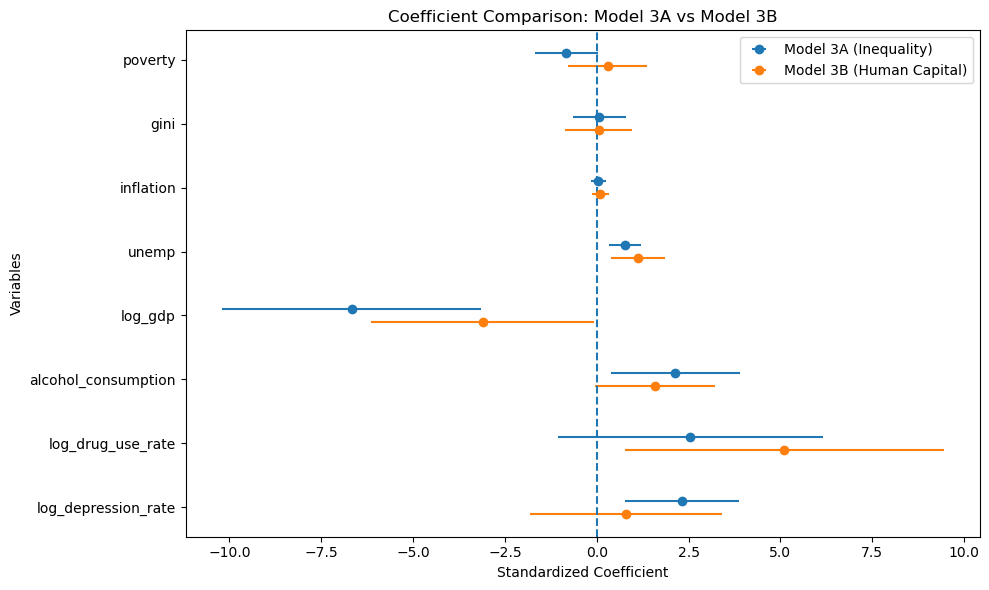

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Variables a mostrar
vars_plot = [
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption",
    "log_gdp",
    "unemp",
    "inflation",
    "gini",
    "poverty"
]

# Extraer coeficientes e intervalos 3A
coef_3A = model_fe_m3A.params[vars_plot]
conf_3A = model_fe_m3A.conf_int().loc[vars_plot]

# Extraer coeficientes e intervalos 3B
coef_3B = model_fe_m3B.params[vars_plot]
conf_3B = model_fe_m3B.conf_int().loc[vars_plot]

# Crear figura
plt.figure(figsize=(10, 6))

y_pos = np.arange(len(vars_plot))

# Modelo 3A
plt.errorbar(
    coef_3A, y_pos + 0.1,
    xerr=[coef_3A - conf_3A[0], conf_3A[1] - coef_3A],
    fmt='o',
    label="Model 3A (Inequality)",
)

# Modelo 3B
plt.errorbar(
    coef_3B, y_pos - 0.1,
    xerr=[coef_3B - conf_3B[0], conf_3B[1] - coef_3B],
    fmt='o',
    label="Model 3B (Human Capital)",
)

plt.axvline(0, linestyle='--')
plt.yticks(y_pos, vars_plot)
plt.title("Coefficient Comparison: Model 3A vs Model 3B")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Variables")
plt.legend()
plt.tight_layout()
plt.show()

# comparision

In [39]:
import pandas as pd

vars_compare = [
    "log_depression_rate",
    "log_drug_use_rate",
    "alcohol_consumption",
    "log_gdp",
    "unemp",
    "inflation",
    "gini",
    "poverty"
]

def build_table(model, model_name):
    coefs = model.params
    pvals = model.pvalues
    
    table = []
    
    for var in vars_compare:
        if var in coefs.index:
            coef = round(coefs[var], 3)
            p = pvals[var]
            
            # Significance stars
            if p < 0.01:
                star = "***"
            elif p < 0.05:
                star = "**"
            elif p < 0.1:
                star = "*"
            else:
                star = ""
                
            table.append(f"{coef}{star}")
        else:
            table.append("")
    
    return pd.Series(table, index=vars_compare, name=model_name)

table_final = pd.concat([
    build_table(model_fe_m2, "Model 2"),
    build_table(model_fe_m3A, "Model 3A"),
    build_table(model_fe_m3B, "Model 3B")
], axis=1)

print(table_final)

                       Model 2   Model 3A  Model 3B
log_depression_rate   1.625***   2.316***     0.798
log_drug_use_rate       3.164*      2.546   5.106**
alcohol_consumption     1.297*    2.138**    1.591*
log_gdp              -3.295***  -6.673***  -3.107**
unemp                 0.872***   0.765***  1.111***
inflation                0.034      0.046       0.1
gini                                0.075      0.05
poverty                           -0.825*     0.303


In [40]:
print("\nObservations:")
print("Model 2:", len(model_df_m2))
print("Model 3A:", len(model_df_m3A))
print("Model 3B:", len(model_df_m3B))


Observations:
Model 2: 3457
Model 3A: 2356
Model 3B: 640


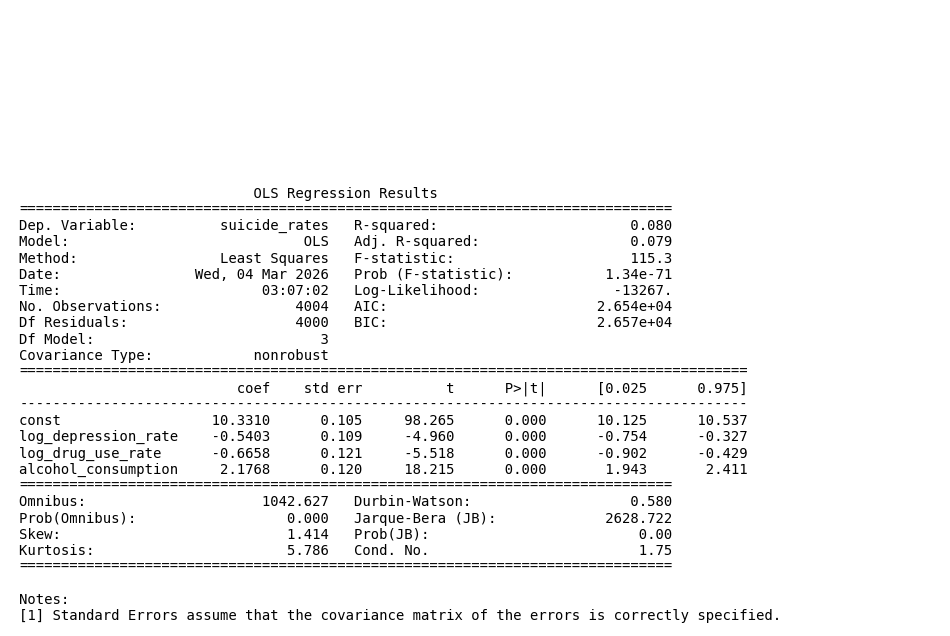

In [45]:
import matplotlib.pyplot as plt

# Convertir el summary a texto
summary_text = model_m1.summary().as_text()

# Crear figura
plt.figure(figsize=(12,8))
plt.text(0.01, 0.01, summary_text, fontsize=10, family="monospace")
plt.axis("off")

# Guardar imagen
plt.savefig("model_m1_summary.png", dpi=300, bbox_inches="tight")

plt.show()

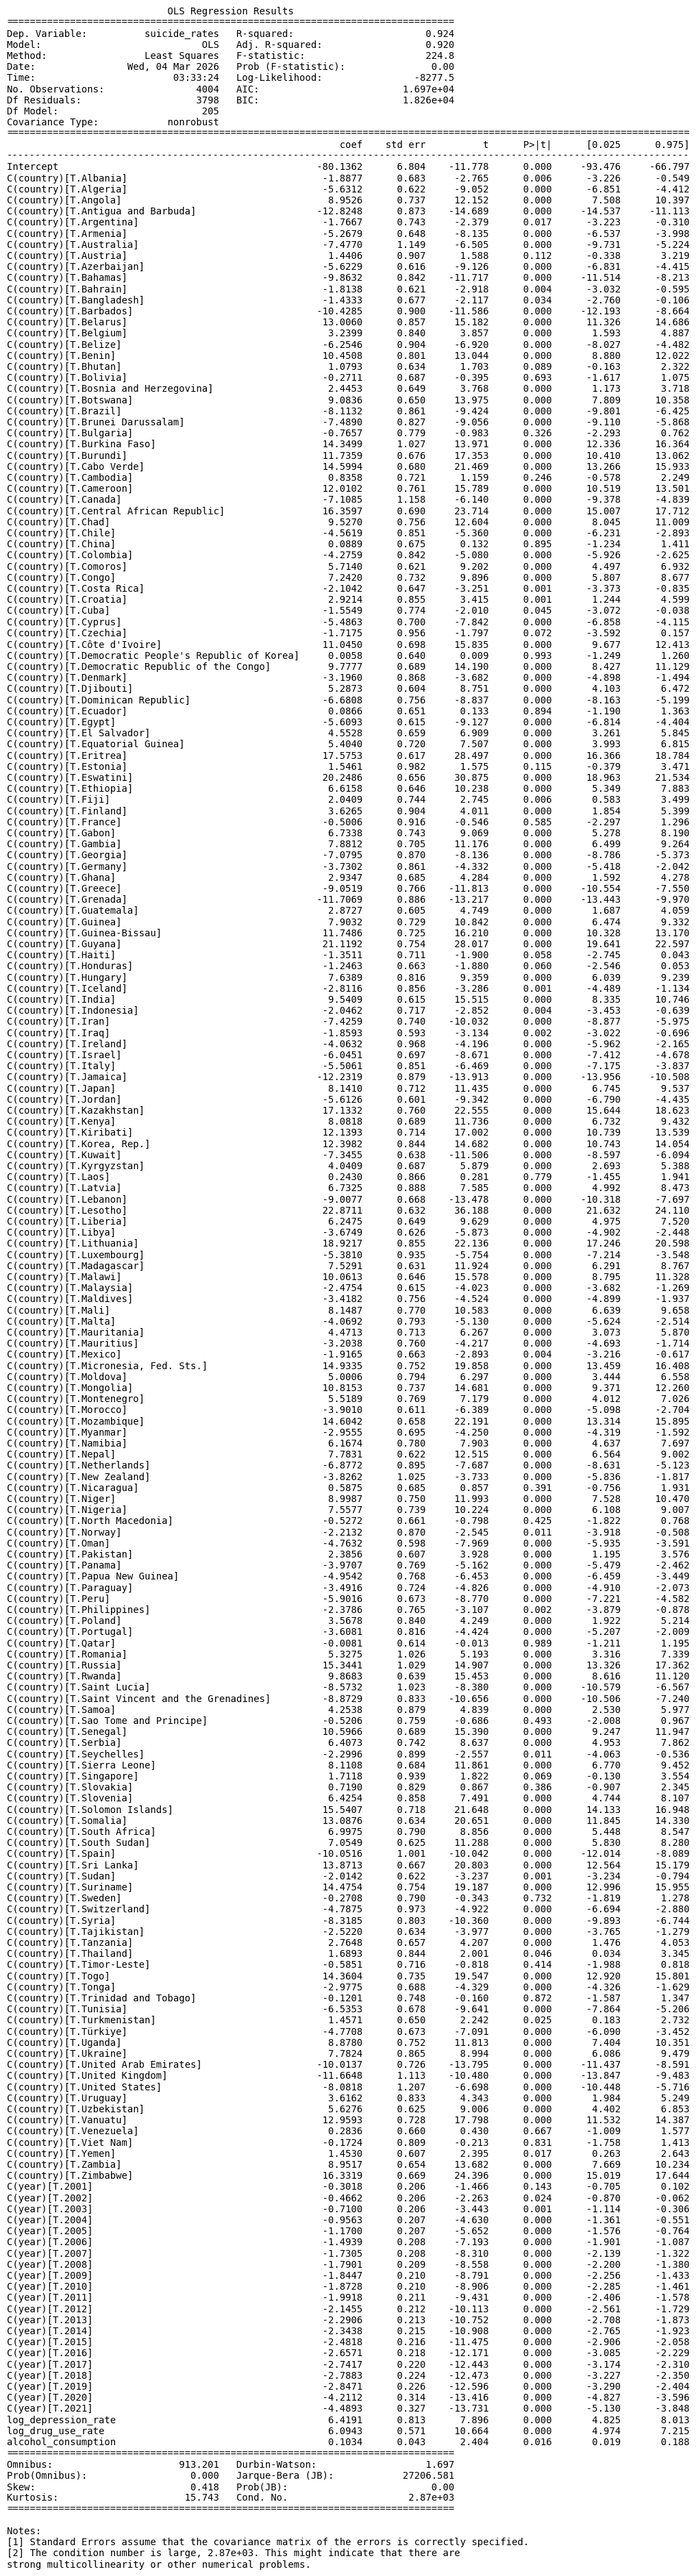

In [46]:
import matplotlib.pyplot as plt

# Obtener el summary como texto
summary_text = model_fe.summary().as_text()

# Crear figura
plt.figure(figsize=(12, 8))
plt.axis('off')

# Insertar el texto en la figura
plt.text(0, 1, summary_text, fontsize=10, family='monospace', va='top')

# Guardar como imagen
plt.savefig("fixed_effects_model_summary.png", bbox_inches="tight", dpi=300)

plt.show()

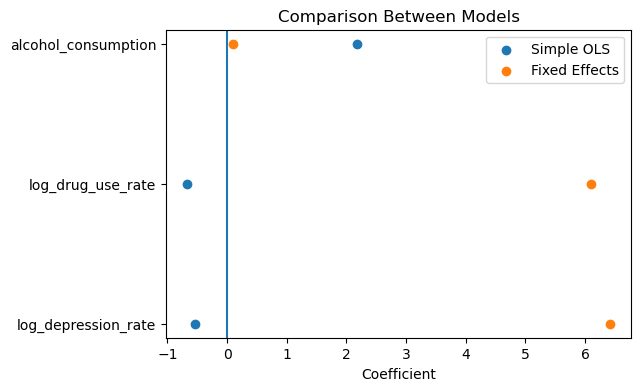

In [48]:
import matplotlib.pyplot as plt

coefs_simple = model_m1.params[variables]
coefs_fe = model_fe.params[variables]

fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(coefs_simple, variables)
ax.scatter(coefs_fe, variables)

ax.axvline(0)
ax.legend(["Simple OLS", "Fixed Effects"])
ax.set_xlabel("Coefficient")
ax.set_title("Comparison Between Models")

# guardar imagen
fig.savefig("model_comparison_coefficients.png", dpi=300, bbox_inches="tight")

plt.show()

In [51]:
# =====================================
# EXPORTAR TODAS LAS TABLAS Y GRÁFICAS
# =====================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Crear carpeta
os.makedirs("results_figures", exist_ok=True)

# =====================================================
# 1. TABLA MODELO 2 (coeficientes + p-values + CI)
# =====================================================

results_m2 = pd.DataFrame({
    "Coefficient": model_fe_m2.params[vars_show],
    "p-value": model_fe_m2.pvalues[vars_show],
    "CI Lower": model_fe_m2.conf_int().loc[vars_show][0],
    "CI Upper": model_fe_m2.conf_int().loc[vars_show][1]
})

fig, ax = plt.subplots()
ax.axis("off")

tbl = ax.table(
    cellText=results_m2.round(4).values,
    colLabels=results_m2.columns,
    rowLabels=results_m2.index,
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2,1.2)

plt.savefig("results_figures/model2_table.png", dpi=300, bbox_inches="tight")
plt.close()


# =====================================================
# 2. GRÁFICA MODELO 2 (coeficientes + CI)
# =====================================================

coefs = model_fe_m2.params[vars_plot]
conf = model_fe_m2.conf_int().loc[vars_plot]

plt.figure()

plt.errorbar(
    coefs,
    range(len(coefs)),
    xerr=[coefs - conf[0], conf[1] - coefs],
    fmt="o"
)

plt.axvline(0)
plt.yticks(range(len(coefs)), vars_plot)
plt.title("Model 2: Coefficients with 95% CI")
plt.xlabel("Effect on suicide_rates")

plt.tight_layout()

plt.savefig("results_figures/model2_coefficients_plot.png", dpi=300, bbox_inches="tight")
plt.close()


# =====================================================
# 3. CAMBIO DE COEFICIENTES (Bloque 1 vs 2)
# =====================================================

plt.figure()

plt.bar(x - 0.2, coef_m1, width=0.4, label="Model 1")
plt.bar(x + 0.2, coef_m2, width=0.4, label="Model 2")

plt.xticks(x, vars_compare)
plt.axhline(0)
plt.title("Coefficient Changes: Block 1 vs Block 2")
plt.legend()

plt.tight_layout()

plt.savefig("results_figures/block1_vs_block2.png", dpi=300, bbox_inches="tight")
plt.close()


# =====================================================
# 4. TABLA MODELO 3A
# =====================================================

results_3A = pd.DataFrame({
    "Coefficient": model_fe_m3A.params[vars_show_3A],
    "p-value": model_fe_m3A.pvalues[vars_show_3A]
})

fig, ax = plt.subplots()
ax.axis("off")

tbl = ax.table(
    cellText=results_3A.round(4).values,
    colLabels=results_3A.columns,
    rowLabels=results_3A.index,
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2,1.2)

plt.savefig("results_figures/model3A_table.png", dpi=300, bbox_inches="tight")
plt.close()


# =====================================================
# 5. TABLA MODELO 3B
# =====================================================

results_3B = pd.DataFrame({
    "Coefficient": model_fe_m3B.params[vars_show_3B],
    "p-value": model_fe_m3B.pvalues[vars_show_3B]
})

fig, ax = plt.subplots()
ax.axis("off")

tbl = ax.table(
    cellText=results_3B.round(4).values,
    colLabels=results_3B.columns,
    rowLabels=results_3B.index,
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2,1.2)

plt.savefig("results_figures/model3B_table.png", dpi=300, bbox_inches="tight")
plt.close()


# =====================================================
# 6. GRÁFICA COMPARACIÓN 3A vs 3B
# =====================================================

coef_3A = model_fe_m3A.params[vars_plot]
conf_3A = model_fe_m3A.conf_int().loc[vars_plot]

coef_3B = model_fe_m3B.params[vars_plot]
conf_3B = model_fe_m3B.conf_int().loc[vars_plot]

plt.figure(figsize=(10,6))

y_pos = np.arange(len(vars_plot))

plt.errorbar(
    coef_3A,
    y_pos + 0.1,
    xerr=[coef_3A - conf_3A[0], conf_3A[1] - coef_3A],
    fmt="o",
    label="Model 3A"
)

plt.errorbar(
    coef_3B,
    y_pos - 0.1,
    xerr=[coef_3B - conf_3B[0], conf_3B[1] - coef_3B],
    fmt="o",
    label="Model 3B"
)

plt.axvline(0, linestyle="--")
plt.yticks(y_pos, vars_plot)

plt.title("Coefficient Comparison: Model 3A vs Model 3B")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Variables")

plt.legend()

plt.tight_layout()

plt.savefig("results_figures/model3A_vs_model3B.png", dpi=300, bbox_inches="tight")
plt.close()


print("Todas las tablas y gráficas fueron guardadas en la carpeta 'results_figures'")

Todas las tablas y gráficas fueron guardadas en la carpeta 'results_figures'
